In [8]:
%load_ext autoreload
%autoreload 2
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import sys
sys.path.insert(0, "../sliptools")
from statData import StatData

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:

# labels = ['from Aditya', 'Aditya specfilt', 'global, no slip', 'no slip', 'wflucs', 'slip']
# suffixes = ['_aditya.txt', '_specfilt.txt', '_gl.txt', '_ns.txt', '_wfluc.txt', '.txt']

labels = ['saved in /projects/.../JSRE', #'Aditya specfilt', #'dynamic test', 
          #'dynamic again', 'dynamic myzd', 
          'with updated subgrid model']#, 'drag coefficient fix']
suffixes = ['_aditya.txt', #'_specfilt.txt', #'_atest.txt',
            #'_dynamic_again.txt', '_dynamic_myzd.txt',
            '_dynamic_myzd_slip.txt']#, '_drag_coeff.txt']

# CUs = ['6', '10', '18']
CUs = ['10']
stats = {}
for label, suffix in zip(labels, suffixes):
    stats[label] = [StatData('CU'+CU+suffix) for CU in CUs]



ustar = 0.443
H = [25] # [9.1, 25, 83]

mean velocity

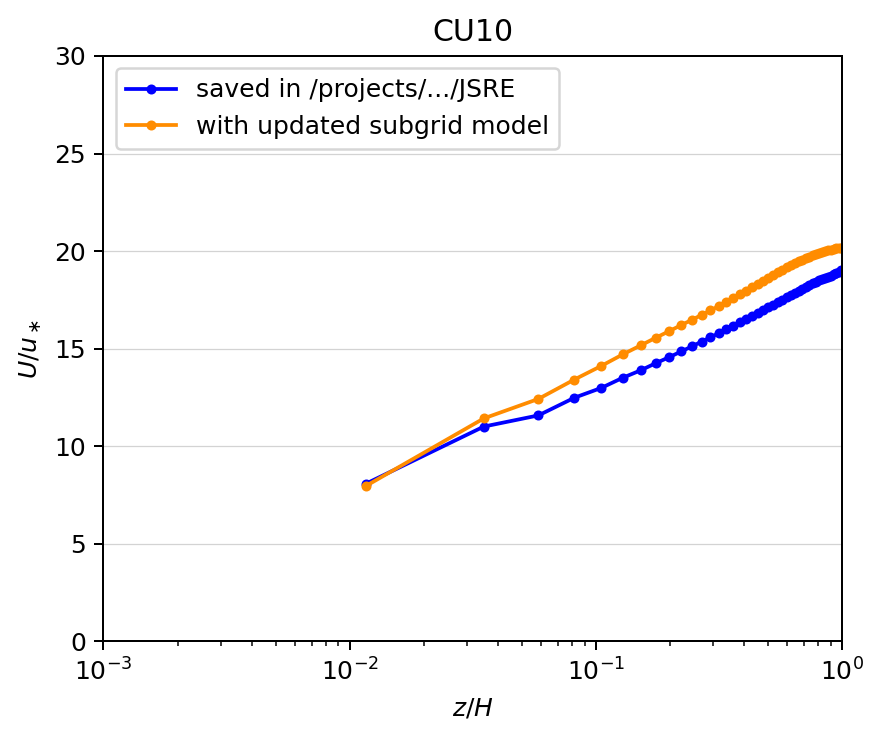

In [18]:
fig, ax = plt.subplots(1,1, figsize=(5,4.2), dpi=180, tight_layout=True)
axs = [ax, ax]
# fig, axs = plt.subplots(1, 3, figsize=(12,4), dpi=180, tight_layout=True, facecolor='w', sharey=True)

# colors = ['black', 'blue', 'darkturquoise', 'purple', 'red', 'darkorange']
colors = ['blue', 'darkorange', 'red']
markers = ['.','.','.','.','.','.']

for CUi in range(len(CUs)):
    ax = axs[CUi]
    for li in range(len(labels)):
        stat = stats[labels[li]][CUi]
        ax.semilogx(stat.data['ym'][1:]/H[CUi], stat.data['U'][1:]/ustar, color=colors[li], marker=markers[li], lw=1.5,
                    label=labels[li])


for axi in range(len(CUs)):
    ax = axs[axi]
    ax.set_xlabel(r'$z/H$')
    ax.set_title('CU'+CUs[axi])
    # ax.set_xlim((9, 11))

axs[0].set_xlim(1e-3,1e0)
axs[0].set_ylim((0,30))
axs[0].set_ylabel(r'$U/u_\ast$')
axs[0].legend(loc='upper left')

axs[0].hlines(np.arange(6)*5, 1e-3, 1e0, colors='lightgray', lw=0.5)

# fig.savefig('wdsm_slip_mean_velocity.png')


$\langle u'w'\rangle$

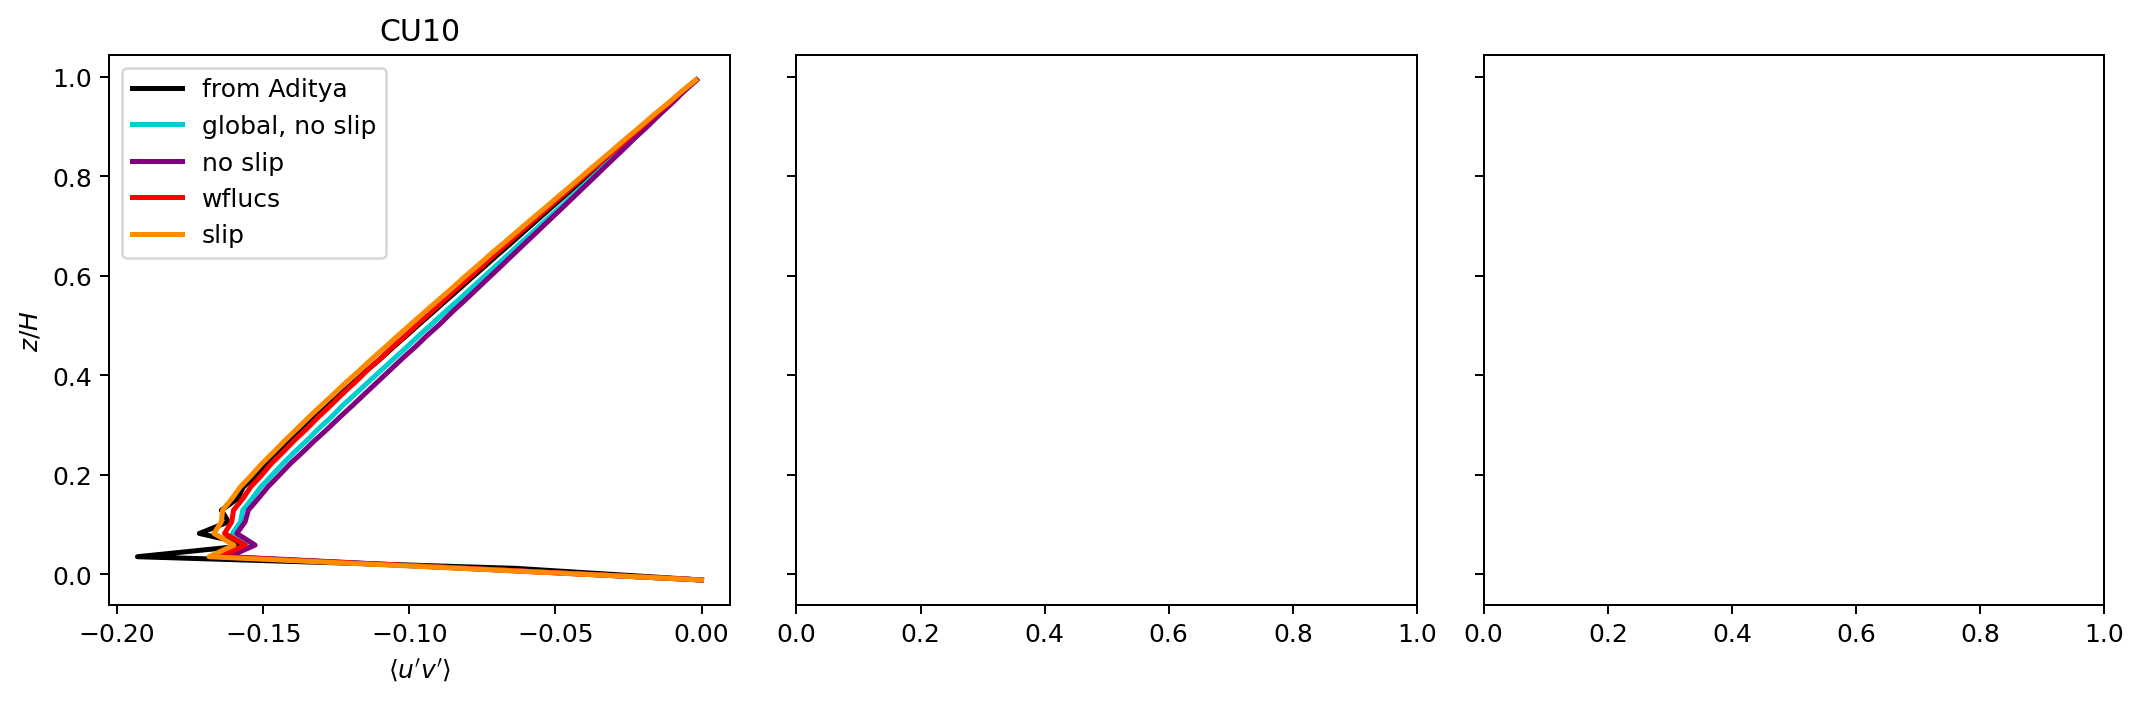

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12,4), dpi=180, tight_layout=True, facecolor='w', sharey=True)

colors = ['black', 'darkturquoise', 'purple', 'red', 'darkorange']

for CUi in range(len(CUs)):
    ax = axs[CUi]
    for li in range(len(labels)):
        stat = stats[labels[li]][CUi]
        ax.plot(stat.data['up_vp'], stat.data['ym']/H[CUi], color=colors[li], lw=2, label=labels[li])


for axi in range(len(CUs)):
    ax = axs[axi]
    ax.set_xlabel(r"$\langle u'v'\rangle$")
    ax.set_title('CU'+CUs[axi])

# axs[0].set_ylim((15,38))
axs[0].set_ylabel(r'$z/H$')
axs[0].legend(loc='upper left')

# fig.savefig('wdsm_slip_upvp.png')


In [22]:
print('ustars from flux: 0-20% of bl height')

print('\n------------------------')
print('CU6')
print('.. no slip: {:.3f}'.format(noslip6.flux_ustar([0,H[0]/5])))
print('.. slip   : {:.3f}'.format(slip6.flux_ustar([0,H[0]/5])))
print('------------------------')

print('\n------------------------')
print('CU10')
print('.. no slip: {:.3f}'.format(noslip10.flux_ustar([0,H[1]/5])))
print('.. slip   : {:.3f}'.format(slip10.flux_ustar([0,H[1]/5])))
print('------------------------')

print('\n------------------------')
print('CU18')
print('.. no slip: {:.3f}'.format(noslip18.flux_ustar([0,H[2]/5])))
print('.. slip   : {:.3f}'.format(slip18.flux_ustar([0,H[2]/5])))
print('------------------------')

ustars from flux: 0-20% of bl height

------------------------
CU6
.. no slip: 0.380
.. slip   : 0.384
------------------------

------------------------
CU10
.. no slip: 0.392
.. slip   : 0.392
------------------------

------------------------
CU18
.. no slip: 0.395
.. slip   : 0.393
------------------------


In [23]:
aditya10 = StatData('noslip-CU10.txt')

print('aditya CU10 ustar: {:.3f}'.format(aditya10.flux_ustar([0,H[1]/5])))

aditya CU10 ustar: 0.391
